In [1]:
# Install
%pip install torch
%pip install torchvision
%pip install matplotlib

### Mount Google Drive

In [2]:
from google.colab import drive
drive.mount("/content/gdrive")

import os
import sys

folder = "/content/gdrive/MyDrive/GoogleDrive/Hiver2026/Tp2/Tp2"

print("folder exists:", os.path.exists(folder))
print("files:", os.listdir(folder)[:20])

os.chdir(folder)
sys.path.append(folder)

print("current folder:", os.getcwd())
print("MLP.py exists:", os.path.exists("MLP.py"))
print("Part1.py exists:", os.path.exists("Part1.py"))

from MLP import FashionMLP
from Part1 import train

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).
folder exists: True
files: ['Devoir_2_IFT3335.pdf', 'MLP.py', 'Part1.py', 'test.py', 'test2.py', '.idea', '.vscode', 'anaconda_projects', 'data', '__pycache__', 'experiments.ipynb']
current folder: /content/gdrive/Othercomputers/My laptop/GoogleDrive/Hiver2026/Tp2/Tp2
MLP.py exists: True
Part1.py exists: True


In [3]:
import os
#je ajoute ce pour le but de plotter les graphes de differents experiments
import pickle

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np

from MLP import FashionMLP
from Part1 import train

In [4]:
# Set seed
seed = 42
torch.manual_seed(seed)
# Set device to GPU if available, otherwise CPU
device = 'cpu'
if torch.cuda.is_available():
    device = 'cuda'
    torch.cuda.manual_seed(seed)

print(f"Using device: {device}")

Using device: cuda


## cellules ajoutées pour le but de plotter les graphes de differents experiments

In [5]:
# je reccupere les metriques de differents experiments
RESULTS_PATH = "results.pkl"


if os.path.exists(RESULTS_PATH):
    with open(RESULTS_PATH, "rb") as f:
        results = pickle.load(f)
    print("Loaded existing results:", results.keys())
else:
    results = {}
    print("Created new empty results dictionary.")

Created new empty results dictionary.


In [6]:
# Préparation de donnée


# Normalement on aurait calculé la moyenne et l'écart-type de Fashion-MNIST, mais ici ils sont donnés
mean = 0.2860
std = 0.3530

# Voici la transformé pour expérience
'''
transform = transforms.Compose([
    transforms.Lambda(lambda img: torch.from_numpy(np.array(img)).float())
])
'''

# Voici la transformé pour le reste des expériences
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((mean,), (std,))
])


# j'ai ajouté cette option non-normaliée, car on en a besion pour l'experiment 1

transform_no_norm = transforms.Compose([
    transforms.Lambda(lambda img: torch.from_numpy(np.array(img)).float())
])



def get_loaders(batch_size, transform):
    os.makedirs("./data", exist_ok=True)

    # Download and load training data
    train_dataset = torchvision.datasets.FashionMNIST(
        root='./data', train=True, transform=transform, download=True
    )

    # Download and load test data
    test_dataset = torchvision.datasets.FashionMNIST(
        root='./data', train=False, transform=transform, download=True
    )
    train_loader = torch.utils.data.DataLoader(
        dataset=train_dataset, batch_size=batch_size, shuffle=True
    )
    test_loader = torch.utils.data.DataLoader(
        dataset=test_dataset, batch_size=batch_size, shuffle=False
    )
    return train_loader, test_loader


In [7]:
class_names = [
    'T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
    'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot'
]

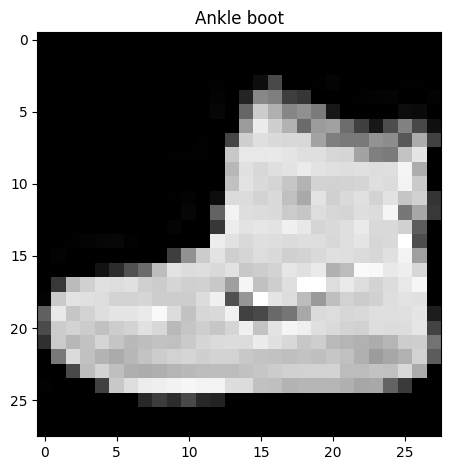

[[[-8.1019837e-01 -8.1019837e-01 -8.1019837e-01 -8.1019837e-01 -8.1019837e-01 -8.1019837e-01 -8.1019837e-01 -8.1019837e-01 -8.1019837e-01 -8.1019837e-01 -8.1019837e-01 -8.1019837e-01 -8.1019837e-01 -8.1019837e-01 -8.1019837e-01 -8.1019837e-01 -8.1019837e-01 -8.1019837e-01 -8.1019837e-01 -8.1019837e-01 -8.1019837e-01 -8.1019837e-01 -8.1019837e-01
   -8.1019837e-01 -8.1019837e-01 -8.1019837e-01 -8.1019837e-01 -8.1019837e-01]
  [-8.1019837e-01 -8.1019837e-01 -8.1019837e-01 -8.1019837e-01 -8.1019837e-01 -8.1019837e-01 -8.1019837e-01 -8.1019837e-01 -8.1019837e-01 -8.1019837e-01 -8.1019837e-01 -8.1019837e-01 -8.1019837e-01 -8.1019837e-01 -8.1019837e-01 -8.1019837e-01 -8.1019837e-01 -8.1019837e-01 -8.1019837e-01 -8.1019837e-01 -8.1019837e-01 -8.1019837e-01 -8.1019837e-01
   -8.1019837e-01 -8.1019837e-01 -8.1019837e-01 -8.1019837e-01 -8.1019837e-01]
  [-8.1019837e-01 -8.1019837e-01 -8.1019837e-01 -8.1019837e-01 -8.1019837e-01 -8.1019837e-01 -8.1019837e-01 -8.1019837e-01 -8.1019837e-01 -8.10198

In [8]:
# Voyons un peu de quoi a l'air le jeu de données
train_dataset = torchvision.datasets.FashionMNIST(
        root='./data', train=True, transform=transform, download=True
    )

np.set_printoptions(linewidth=350)

image_tensor, label_idx = train_dataset[0]
image_numpy = image_tensor.squeeze().numpy()
fig = plt.figure()
plt.imshow(image_numpy, cmap='gray')
plt.title(class_names[label_idx])
plt.tight_layout()
plt.show()
print(image_tensor.numpy())

In [9]:
# Voici un fonction pour visualiser quelques exemples
def visualize_samples(dataset, num_samples=10):
    """
    Plots a grid of random images from the dataset with their labels.
    """
    fig = plt.figure(figsize=(12, 5))

    for i in range(num_samples):
        idx = np.random.randint(0, len(dataset))
        image_tensor, label_idx = dataset[idx]
        image_numpy = image_tensor.squeeze().numpy()
        ax = fig.add_subplot(2, 5, i + 1, xticks=[], yticks=[])
        ax.imshow(image_numpy, cmap='gray')
        ax.set_title(class_names[label_idx])
    plt.tight_layout()
    plt.show()

Total number of training images: 60000
Displaying random samples...


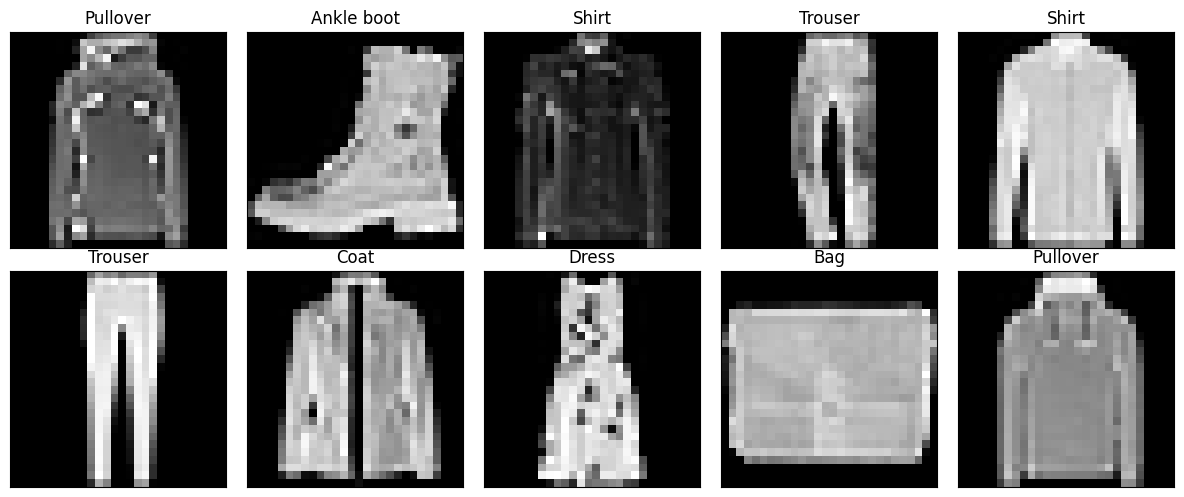

In [10]:
print(f"Total number of training images: {len(train_dataset)}")
print("Displaying random samples...")

visualize_samples(train_dataset, num_samples=10)

In [11]:
def mse_los(outputs, labels):
    targets_one_hot = F.one_hot(labels, num_classes=outputs.size(1)).float()
    probs = F.softmax(outputs, dim=1)
    return F.mse_loss(probs, targets_one_hot)

def hinge_loss_simple(outputs, labels, margin=1.0):
    correct_scores = outputs.gather(1, labels.view(-1, 1))
    margins = outputs - correct_scores + margin
    loss = torch.max(torch.zeros_like(margins), margins)
    loss.scatter_(1, labels.view(-1, 1), 0)
    return loss.sum(1).mean()

## cellules ajoutées pour le but de plotter les graphes de differents experiments

In [12]:
def get_criterion(loss_name):
    if loss_name == "CE":
        return nn.CrossEntropyLoss()
    elif loss_name == "Hinge":
        return hinge_loss_simple
    elif loss_name == "MSE":
        return mse_los
    else:
        raise ValueError(f"Unknown loss: {loss_name}")

## parametres pour les differents experiments

In [13]:
INPUT_SIZE = 28 * 28
OUTPUT_SIZE = 10

experiments = {
    "Baseline": {
        "normalize": True,
        "h1": 64,
        "h2": 64,
        "lr": 0.05,
        "loss": "CE",
        "batch_size": 64,
        "epochs": 20,
    },
    "1": {
        "normalize": False,
        "h1": 64,
        "h2": 64,
        "lr": 0.05,
        "loss": "CE",
        "batch_size": 64,
        "epochs": 20,
    },
    "2": {
        "normalize": True,
        "h1": 70,
        "h2": 0,
        "lr": 0.05,
        "loss": "CE",
        "batch_size": 64,
        "epochs": 20,
    },
    "3": {
        "normalize": True,
        "h1": 64,
        "h2": 64,
        "lr": 0.1,
        "loss": "CE",
        "batch_size": 64,
        "epochs": 20,
    },
    "4": {
        "normalize": True,
        "h1": 64,
        "h2": 64,
        "lr": 0.01,
        "loss": "CE",
        "batch_size": 64,
        "epochs": 20,
    },
    "5": {
        "normalize": True,
        "h1": 64,
        "h2": 64,
        "lr": 0.05,
        "loss": "Hinge",
        "batch_size": 64,
        "epochs": 20,
    },
    "6": {
        "normalize": True,
        "h1": 64,
        "h2": 64,
        "lr": 0.05,
        "loss": "MSE",
        "batch_size": 64,
        "epochs": 20,
    },
    "7": {
        "normalize": True,
        "h1": 48,
        "h2": 300,
        "lr": 0.05,
        "loss": "CE",
        "batch_size": 64,
        "epochs": 20,
    },
    "8": {
        "normalize": True,
        "h1": 300,
        "h2": 48,
        "lr": 0.05,
        "loss": "CE",
        "batch_size": 64,
        "epochs": 20,
    },
    "9": {
        "normalize": True,
        "h1": 64,
        "h2": 64,
        "lr": 0.05,
        "loss": "CE",
        "batch_size": 2,
        "epochs": 20,
    },
}

## Function pour executer une seule experiment

In [14]:
def run_experiment(exp_name, cfg):
    print("=" * 70)
    print(f"Execusion de l'experiment: {exp_name}")
    print(cfg)

    if cfg["normalize"]:
        chosen_transform = transform
    else:
        chosen_transform = transform_no_norm

    train_loader, test_loader = get_loaders(
        batch_size=cfg["batch_size"],
        transform=chosen_transform
    )

    model = FashionMLP(
        input_size=INPUT_SIZE,
        h1_size=cfg["h1"],
        h2_size=cfg["h2"],
        output_size=OUTPUT_SIZE,
        activation1=nn.Sigmoid(),
        activation2=nn.Sigmoid()
    ).to(device)

    criterion = get_criterion(cfg["loss"])

    optimizer = optim.SGD(
        model.parameters(),
        lr=cfg["lr"]
    )

    train_losses, test_losses, train_accuracies, test_accuracies = train(
        model=model,
        epochs=cfg["epochs"],
        optimizer=optimizer,
        criterion=criterion,
        train_loader=train_loader,
        test_loader=test_loader,
        device=device
    )

    results[exp_name] = {
        "config": cfg,
        "train_losses": train_losses,
        "test_losses": test_losses,
        "train_accuracies": train_accuracies,
        "test_accuracies": test_accuracies,
    }

    with open(RESULTS_PATH, "wb") as f:
        pickle.dump(results, f)

    print(f"Les  metriques pour experiment {exp_name}")

    return model, train_loader, test_loader

##pour executer toutes les experiments

In [15]:
for exp_name, cfg in experiments.items():
    if exp_name in results:
        print(f"Skipping {exp_name}: already saved.")
    else:
        model, train_loader, test_loader = run_experiment(exp_name, cfg)

Execusion de l'experiment: Baseline
{'normalize': True, 'h1': 64, 'h2': 64, 'lr': 0.05, 'loss': 'CE', 'batch_size': 64, 'epochs': 20}
Starting training...
Epoch [1/20] | Train Loss: 1.6181 | Test Loss: 1.1171 | Train Accuracy: 44.61 | Test Accuracy: 59.54%
Epoch [2/20] | Train Loss: 0.9149 | Test Loss: 0.7714 | Train Accuracy: 68.05 | Test Accuracy: 71.38%
Epoch [3/20] | Train Loss: 0.6758 | Test Loss: 0.6315 | Train Accuracy: 75.41 | Test Accuracy: 76.75%
Epoch [4/20] | Train Loss: 0.5708 | Test Loss: 0.5554 | Train Accuracy: 79.17 | Test Accuracy: 79.82%
Epoch [5/20] | Train Loss: 0.5068 | Test Loss: 0.5100 | Train Accuracy: 82.27 | Test Accuracy: 81.61%
Epoch [6/20] | Train Loss: 0.4656 | Test Loss: 0.4812 | Train Accuracy: 83.71 | Test Accuracy: 82.85%
Epoch [7/20] | Train Loss: 0.4366 | Test Loss: 0.4613 | Train Accuracy: 84.67 | Test Accuracy: 83.55%
Epoch [8/20] | Train Loss: 0.4155 | Test Loss: 0.4443 | Train Accuracy: 85.33 | Test Accuracy: 84.34%
Epoch [9/20] | Train Loss: 0.

## pour plotter les graphes

In [16]:
print(results.keys())

dict_keys(['Baseline', '1', '2', '3', '4', '5', '6', '7', '8', '9'])


In [17]:
def plot_group(exp_names, metric_name, title, ylabel):
    plt.figure(figsize=(9, 5))

    for exp_name in exp_names:
        train_metric = results[exp_name][f"train_{metric_name}"]
        test_metric = results[exp_name][f"test_{metric_name}"]

        epochs = range(1, len(train_metric) + 1)

        plt.plot(
            epochs,
            train_metric,
            marker="o",
            label=f"{exp_name} train"
        )

        plt.plot(
            epochs,
            test_metric,
            marker="x",
            linestyle="--",
            label=f"{exp_name} test"
        )

    plt.xlabel("Epoch")
    plt.ylabel(ylabel)
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()

    filename = title.replace(" ", "_").replace(":", "") + ".png"
    plt.savefig(filename)

    plt.show()

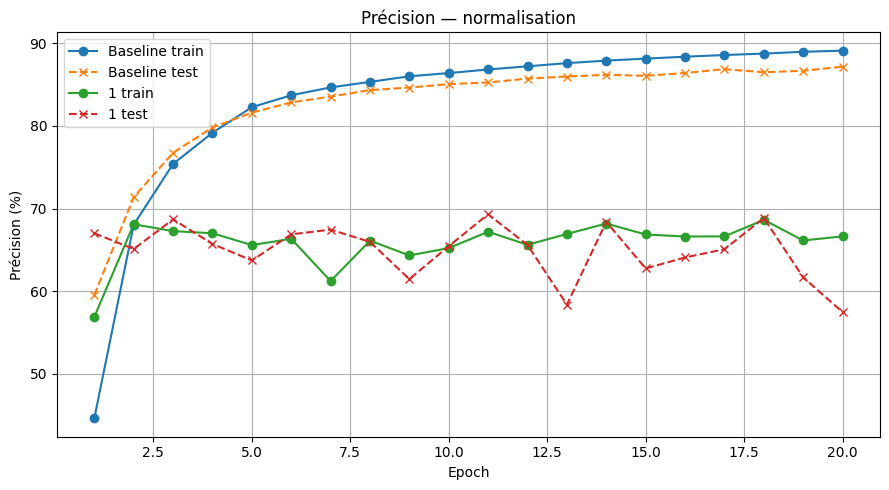

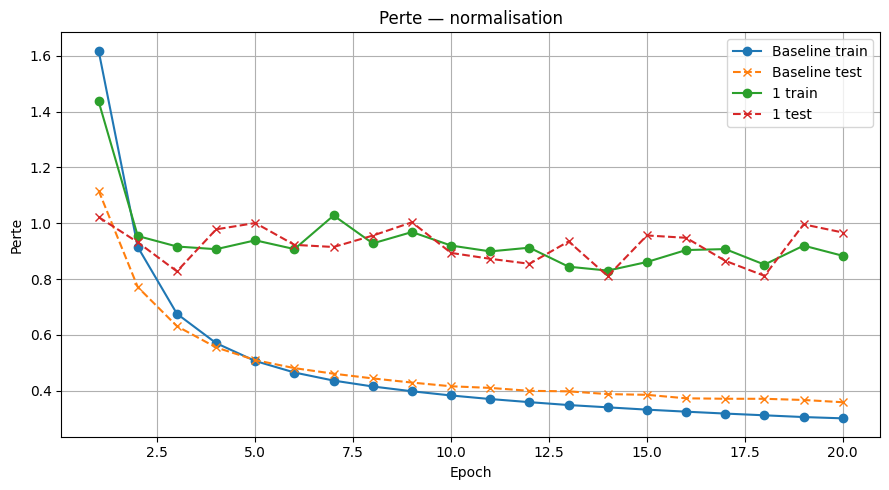

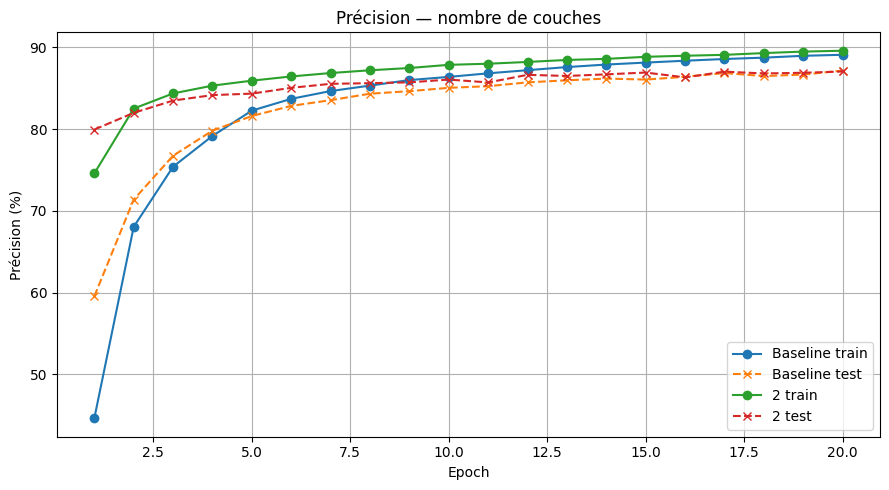

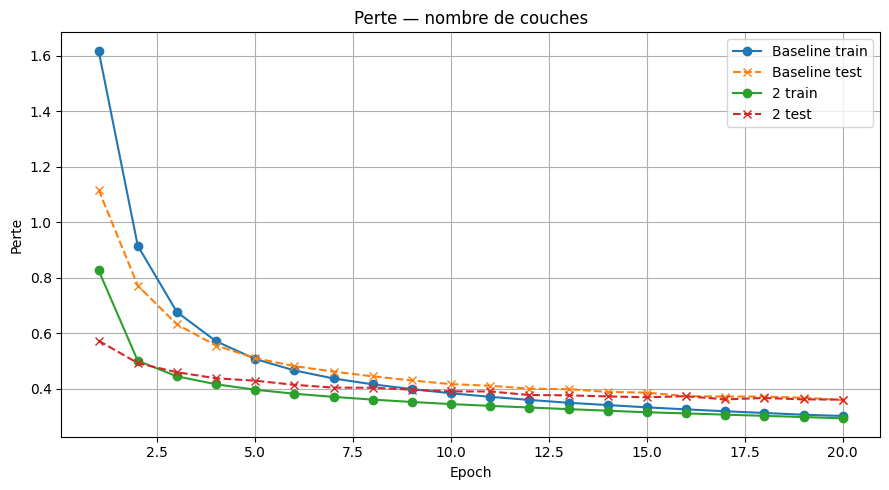

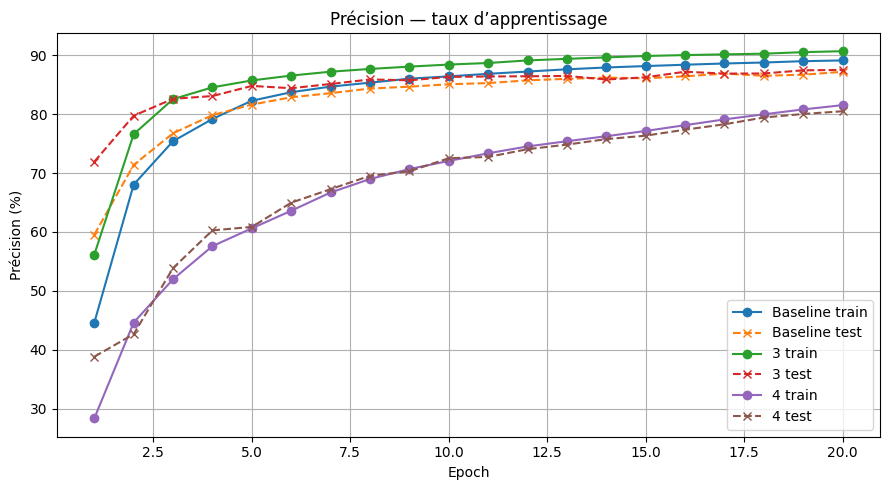

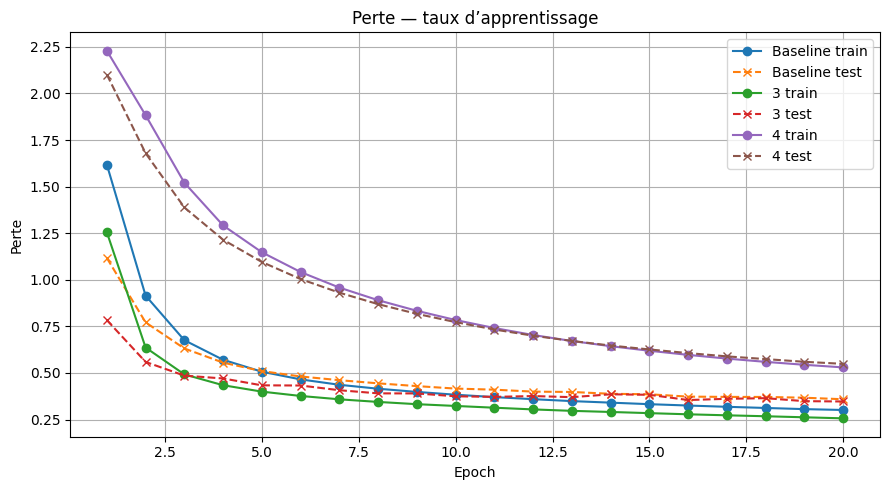

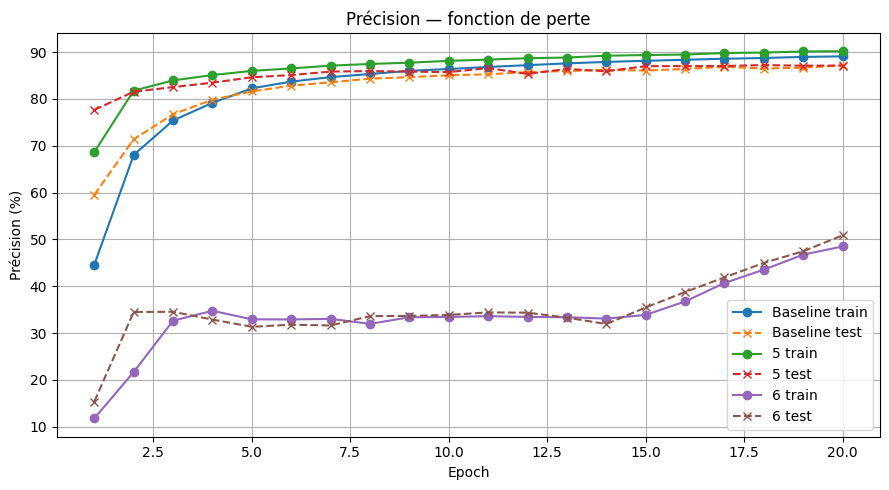

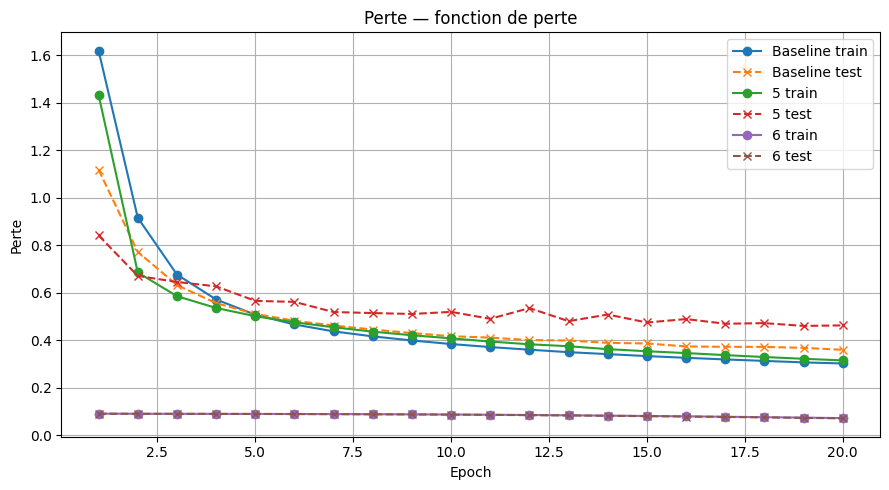

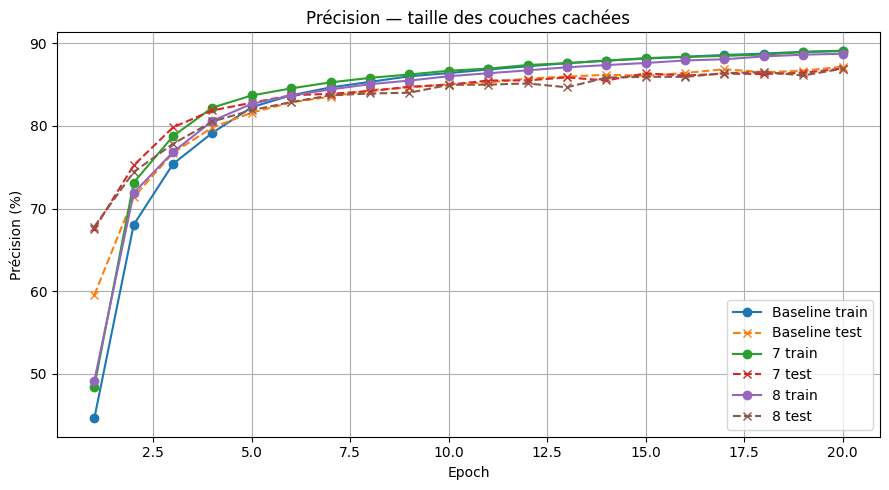

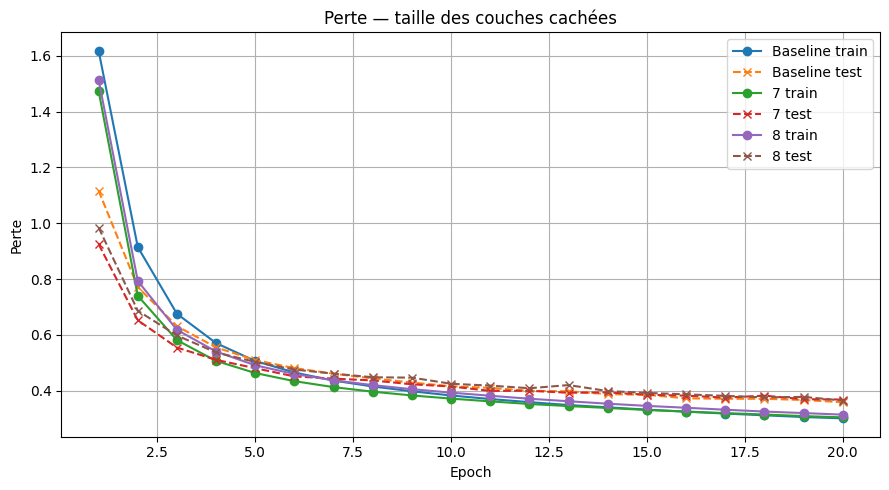

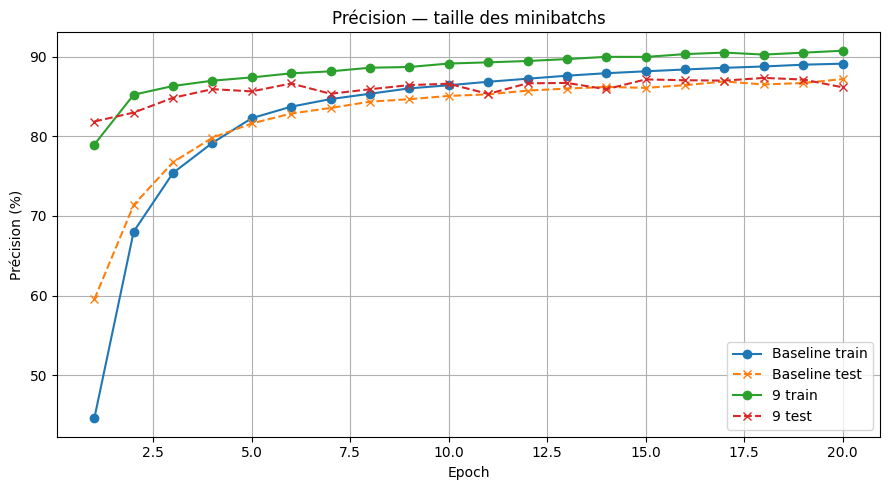

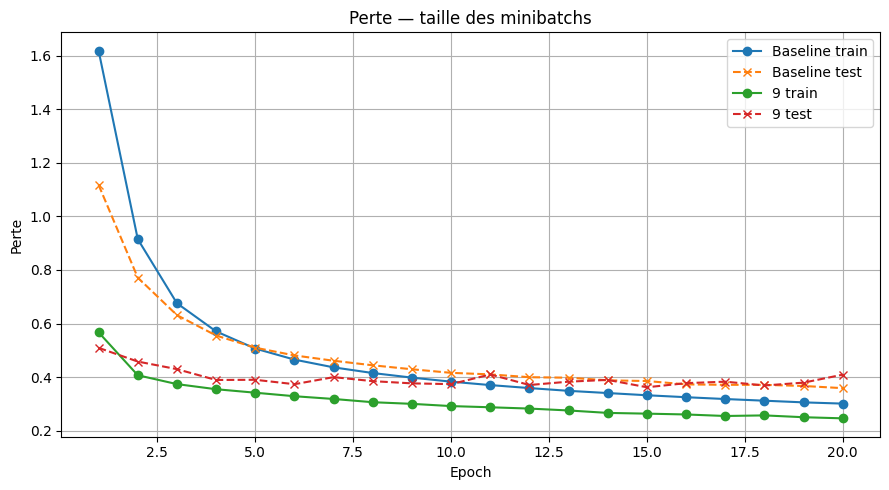

In [18]:
# Expérience 1: normalisation
plot_group(
    ["Baseline", "1"],
    "accuracies",
    "Précision — normalisation",  #
    "Précision (%)"               #
)

plot_group(
    ["Baseline", "1"],
    "losses",
    "Perte — normalisation",  #
    "Perte"                   #
)


# Expérience 2: nombre de couches
plot_group(
    ["Baseline", "2"],
    "accuracies",
    "Précision — nombre de couches",  #
    "Précision (%)"                   #
)

plot_group(
    ["Baseline", "2"],
    "losses",
    "Perte — nombre de couches",  #
    "Perte"                       #
)


# Expérience 3: taux d’apprentissage
plot_group(
    ["Baseline", "3", "4"],
    "accuracies",
    "Précision — taux d’apprentissage",  #
    "Précision (%)"                      #
)

plot_group(
    ["Baseline", "3", "4"],
    "losses",
    "Perte — taux d’apprentissage",  #
    "Perte"                          #
)


# Expérience 4: fonction de perte
plot_group(
    ["Baseline", "5", "6"],
    "accuracies",
    "Précision — fonction de perte",  #
    "Précision (%)"                   #
)

plot_group(
    ["Baseline", "5", "6"],
    "losses",
    "Perte — fonction de perte",  #
    "Perte"                       #
)


# Expérience 5: taille des couches cachées
plot_group(
    ["Baseline", "7", "8"],
    "accuracies",
    "Précision — taille des couches cachées",  #
    "Précision (%)"                            #
)

plot_group(
    ["Baseline", "7", "8"],
    "losses",
    "Perte — taille des couches cachées",  #
    "Perte"                                #
)


# Expérience 6: taille des minibatchs
plot_group(
    ["Baseline", "9"],
    "accuracies",
    "Précision — taille des minibatchs",  #
    "Précision (%)"                       #
)

plot_group(
    ["Baseline", "9"],
    "losses",
    "Perte — taille des minibatchs",  #
    "Perte"                           #
)

In [19]:
# Une fonction sympa pour voir les exemples mal classifiés
def get_model_failures(model, loader, device):
    """
    Runs the model on the loader and returns a list of (image, true_label, predicted_label)
    for every instance where the model was wrong.
    """
    model.eval()
    failures = []

    print("Analyzing test set for failures...")
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            mask = predicted != labels
            wrong_imgs = images[mask].cpu()
            wrong_labels = labels[mask].cpu()
            wrong_preds = predicted[mask].cpu()

            for i in range(len(wrong_imgs)):
                failures.append((wrong_imgs[i], wrong_labels[i].item(), wrong_preds[i].item()))

    print(f"Analysis complete. Model failed on {len(failures)} images.")
    return failures

def visualize_failures(failures, class_names, num_samples=10):
    """
    Specialized visualization for failures to show what the model
    thought the image was versus reality.
    """
    if not failures:
        print("No failures to display!")
        return

    num_samples = min(num_samples, len(failures))
    fig = plt.figure(figsize=(15, 7))

    indices = np.random.choice(len(failures), num_samples, replace=False)

    for i, idx in enumerate(indices):
        image_tensor, true_label, pred_label = failures[idx]

        image_numpy = image_tensor.squeeze().numpy()

        ax = fig.add_subplot(2, 5, i + 1, xticks=[], yticks=[])
        ax.imshow(image_numpy, cmap='gray')

        title = f"True: {class_names[true_label]}\nPred: {class_names[pred_label]}"
        ax.set_title(title, fontsize=10)

    plt.tight_layout()
    plt.suptitle("Model Misclassifications", fontsize=16, y=1.05)
    plt.show()

In [20]:
visualize_failures(failed_data, class_names, num_samples=10)

NameError: name 'failed_data' is not defined